In this notebook, the IMU data is smoothed by using rolling window mean and its impact is measured.
In the raw IMU data, spikes of the sensor values are observed in the sequence 09. The hypothesis is that removing the spikes of the IMU data resulting in smoothed IMU readings might affect on the prediction accracy. Hence the following setups are made:
- Collect all the filters result
- Collect the results of all filters, where IMU data is smoothed with the window size 5
- Collect the results of all filters, where IMU data is smoothed with the window size 10
- Compare the results.


In [1]:
import numpy as np
import pandas as pd
import sys
sys.path.append('../../src')
from data_loader import DataLoader
from configs.configs import SetupEnum, SamplingEnum, ErrorEnum, FilterEnum, NoiseTypeEnum
from kalman_filters.extended_kalman_filter import ExtendedKalmanFilter
from kalman_filters.unscented_kalman_filter import UnscentedKalmanFilter
from kalman_filters.ensemble_kalman_filter import EnsembleKalmanFilter
from kalman_filters.cubature_kalman_filter import CubatureKalmanFilter
from kalman_filters.particle_filter import ParticleFilter, ResamplingAlgorithms
from utils.error_report import get_error_from_list


%matplotlib inline
np.random.seed(777)

Data size: 1591
Shape:
GPS: (1591, 3)
VO: (1591, 3)
IMU: (1591, 6)
INS angle: (1591, 3)
INS velocity: (1591, 3)
Add noise to GPS data
Adding noise to VO data
Adding noise to IMU sensor data
Adding noise to linear acceleration
Adding noise to angular velocity
Adding noise to INS sensor data
Adding noise to linear velocity data
Adding noise to angle data
Data sampling is set to normal mode.


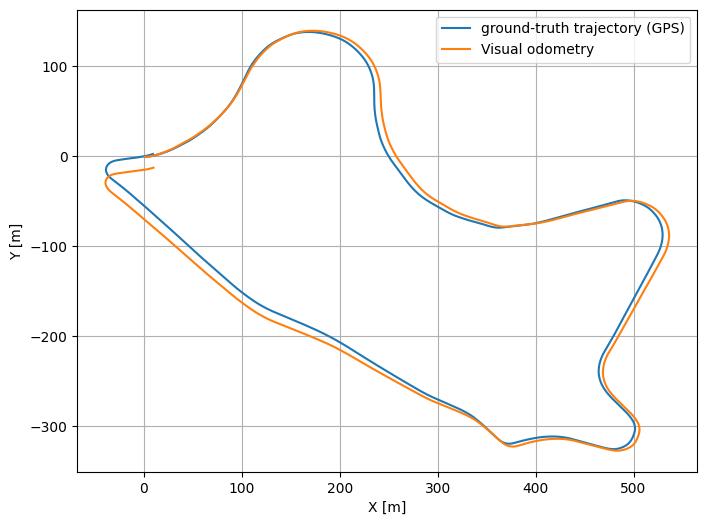

In [2]:
kitti_root_dir = '../../data'
vo_root_dir = '../../vo_estimates'
noise_vector_dir = '../../exports/_noise_optimizations/noise_vectors'
kitti_date = '2011_09_30'
kitti_drive = '0033'

data = DataLoader(sequence_nr=kitti_drive, 
                  kitti_root_dir=kitti_root_dir, 
                  vo_root_dir=vo_root_dir,
                  noise_vector_dir=noise_vector_dir,
                  vo_dropout_ratio=0.0, 
                  gps_dropout_ratio=0.0,
                  visualize_data=True
                 )

In [3]:
alpha_setup1_0 = 1.0
beta_setup1_0 = 6.0
kappa_setup1_0 = 0.0

alpha_setup2_0 = 1.0
beta_setup2_0 = 6.0
kappa_setup2_0 = 0.0

alpha_setup3_0 = 0.0001
beta_setup3_0 = 4.0
kappa_setup3_0 = 0.0

n_samples_setup1_0 = 2048
resampling_algorithm_setup1_0 = ResamplingAlgorithms.STRATIFIED
n_samples_setup2_0 = 2048
resampling_algorithm_setup2_0 = ResamplingAlgorithms.RESIDUAL
n_samples_setup3_0 = 2048
resampling_algorithm_setup3_0 = ResamplingAlgorithms.STRATIFIED

n_ensemble_setup1_0 = 32
n_ensemble_setup2_0 = 512
n_ensemble_setup3_0 = 64

# Tightly-Coupled (Current implementation)

In [4]:
x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(setup=SetupEnum.SETUP_1, 
                                                                        filter_type=FilterEnum.EKF,
                                                                        noise_type=NoiseTypeEnum.CURRENT)
x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(setup=SetupEnum.SETUP_2, 
                                                                        filter_type=FilterEnum.EKF, 
                                                                        noise_type=NoiseTypeEnum.CURRENT)
x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(setup=SetupEnum.SETUP_3, 
                                                                        filter_type=FilterEnum.EKF, 
                                                                        noise_type=NoiseTypeEnum.CURRENT)
ekf1_0 = ExtendedKalmanFilter(
    x=x_setup1.copy(),
    P=P_setup1.copy(), 
    H=H_setup1.copy(),
    q=q1,
    r_vo=r_vo1,
    r_gps=r_gps1,
    setup=SetupEnum.SETUP_1)

ekf2_0 = ExtendedKalmanFilter(
    x=x_setup2.copy(), 
    P=P_setup2.copy(), 
    H=H_setup2.copy(),
    q=q2,
    r_vo=r_vo2,
    r_gps=r_gps2,
    setup=SetupEnum.SETUP_2)

ekf3_0 = ExtendedKalmanFilter(
    x=x_setup3.copy(), 
    P=P_setup3.copy(), 
    H=H_setup3.copy(),
    q=q3,
    r_vo=r_vo3,
    r_gps=r_gps3,
    setup=SetupEnum.SETUP_3)

error_ekf_1 = ekf1_0.run(data=data, debug_mode=True, show_graph=False)
error_ekf_2 = ekf2_0.run(data=data, debug_mode=True, show_graph=False)
error_ekf_3 = ekf3_0.run(data=data, debug_mode=True, show_graph=False)

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(setup=SetupEnum.SETUP_1, 
                                                                        filter_type=FilterEnum.UKF, 
                                                                        noise_type=NoiseTypeEnum.CURRENT)
x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(setup=SetupEnum.SETUP_2, 
                                                                        filter_type=FilterEnum.UKF, 
                                                                        noise_type=NoiseTypeEnum.CURRENT)
x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(setup=SetupEnum.SETUP_3, 
                                                                        filter_type=FilterEnum.UKF, 
                                                                        noise_type=NoiseTypeEnum.CURRENT)
ukf1_0 = UnscentedKalmanFilter(
    x=x_setup1.copy(), 
    P=P_setup1.copy(), 
    H=H_setup1.copy(), 
    q=q1,
    r_vo=r_vo1,
    r_gps=r_gps1,
    alpha=alpha_setup1_0, 
    beta=beta_setup1_0, 
    kappa=kappa_setup1_0,
    setup=SetupEnum.SETUP_1)

ukf2_0 = UnscentedKalmanFilter(
    x=x_setup2.copy(), 
    P=P_setup2.copy(), 
    H=H_setup2.copy(), 
    q=q2,
    r_vo=r_vo2,
    r_gps=r_gps2,
    alpha=alpha_setup2_0, 
    beta=beta_setup2_0, 
    kappa=kappa_setup2_0,
    setup=SetupEnum.SETUP_2)

ukf3_0 = UnscentedKalmanFilter(
    x=x_setup3.copy(), 
    P=P_setup3.copy(), 
    H=H_setup3.copy(), 
    q=q3,
    r_vo=r_vo3,
    r_gps=r_gps3,
    alpha=alpha_setup3_0, 
    beta=beta_setup3_0, 
    kappa=kappa_setup3_0,
    setup=SetupEnum.SETUP_3)
error_ukf_1 = ukf1_0.run(data=data, debug_mode=True, show_graph=False)
error_ukf_2 = ukf2_0.run(data=data, debug_mode=True, show_graph=False)
error_ukf_3 = ukf3_0.run(data=data, debug_mode=True, show_graph=False)

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(setup=SetupEnum.SETUP_1, 
                                                                        filter_type=FilterEnum.PF, 
                                                                        noise_type=NoiseTypeEnum.CURRENT)
x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(setup=SetupEnum.SETUP_2, 
                                                                        filter_type=FilterEnum.PF, 
                                                                        noise_type=NoiseTypeEnum.CURRENT)
x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(setup=SetupEnum.SETUP_3, 
                                                                        filter_type=FilterEnum.PF, 
                                                                        noise_type=NoiseTypeEnum.CURRENT)

pf1_0 = ParticleFilter(
    N=n_samples_setup1_0, 
    x_dim=x_setup1.shape[0], 
    H=H_setup1.copy(), 
    q=q1,
    r_vo=r_vo1,
    r_gps=r_gps1,
    setup=SetupEnum.SETUP_1,
    resampling_algorithm=resampling_algorithm_setup1_0)

pf1_0.create_gaussian_particles(mean=x_setup1.copy(), var=P_setup1.copy())

pf2_0 = ParticleFilter(
    N=n_samples_setup2_0, 
    x_dim=x_setup2.shape[0], 
    H=H_setup2.copy(), 
    q=q2,
    r_vo=r_vo2,
    r_gps=r_gps2,
    setup=SetupEnum.SETUP_2,
    resampling_algorithm=resampling_algorithm_setup2_0)

pf2_0.create_gaussian_particles(mean=x_setup2.copy(), var=P_setup2.copy())

pf3_0 = ParticleFilter(
    N=n_samples_setup3_0, 
    x_dim=x_setup3.shape[0], 
    H=H_setup3.copy(), 
    q=q3,
    r_vo=r_vo3,
    r_gps=r_gps3,
    setup=SetupEnum.SETUP_3,
    resampling_algorithm=resampling_algorithm_setup3_0)

pf3_0.create_gaussian_particles(mean=x_setup3.copy(), var=P_setup3.copy())

error_pf_1 = pf1_0.run(data=data, debug_mode=True, show_graph=False)
error_pf_2 = pf2_0.run(data=data, debug_mode=True, show_graph=False)
error_pf_3 = pf3_0.run(data=data, debug_mode=True, show_graph=False)


x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(setup=SetupEnum.SETUP_1, 
                                                                        filter_type=FilterEnum.EnKF, 
                                                                        noise_type=NoiseTypeEnum.CURRENT)
x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(setup=SetupEnum.SETUP_2, 
                                                                        filter_type=FilterEnum.EnKF, 
                                                                        noise_type=NoiseTypeEnum.CURRENT)
x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(setup=SetupEnum.SETUP_3, 
                                                                        filter_type=FilterEnum.EnKF, 
                                                                        noise_type=NoiseTypeEnum.CURRENT)

enkf1_0 = EnsembleKalmanFilter(        
    N=n_ensemble_setup1_0, 
    x=x_setup1.copy(), 
    P=P_setup1.copy(), 
    H=H_setup1.copy(),
    q=q1,
    r_vo=r_vo1,
    r_gps=r_gps1,
    setup=SetupEnum.SETUP_1)
enkf2_0 = EnsembleKalmanFilter(
    N=n_ensemble_setup2_0, 
    x=x_setup2.copy(), 
    P=P_setup2.copy(), 
    H=H_setup2.copy(),
    q=q2,
    r_vo=r_vo2,
    r_gps=r_gps2,
    setup=SetupEnum.SETUP_2)

enkf3_0 = EnsembleKalmanFilter(
    N=n_ensemble_setup3_0, 
    x=x_setup3.copy(), 
    P=P_setup3.copy(), 
    H=H_setup3.copy(),
    q=q3,
    r_vo=r_vo3,
    r_gps=r_gps3,
    setup=SetupEnum.SETUP_3)

error_enkf_1 = enkf1_0.run(data=data, debug_mode=True, show_graph=False)
error_enkf_2 = enkf2_0.run(data=data, debug_mode=True, show_graph=False)
error_enkf_3 = enkf3_0.run(data=data, debug_mode=True, show_graph=False)

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(setup=SetupEnum.SETUP_1, 
                                                                        filter_type=FilterEnum.CKF, 
                                                                        noise_type=NoiseTypeEnum.CURRENT)
x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(setup=SetupEnum.SETUP_2, 
                                                                        filter_type=FilterEnum.CKF, 
                                                                        noise_type=NoiseTypeEnum.CURRENT)
x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(setup=SetupEnum.SETUP_3, 
                                                                        filter_type=FilterEnum.CKF, 
                                                                        noise_type=NoiseTypeEnum.CURRENT)

ckf1_0 = CubatureKalmanFilter(
    x=x_setup1.copy(), 
    P=P_setup1.copy(), 
    H=H_setup1.copy(),
    q=q1,
    r_vo=r_vo1,
    r_gps=r_gps1,
    setup=SetupEnum.SETUP_1)

ckf2_0 = CubatureKalmanFilter(
    x=x_setup2.copy(), 
    P=P_setup2.copy(), 
    H=H_setup2.copy(),
    q=q2,
    r_vo=r_vo2,
    r_gps=r_gps2,
    setup=SetupEnum.SETUP_2)

ckf3_0 = CubatureKalmanFilter( 
    x=x_setup3.copy(), 
    P=P_setup3.copy(), 
    H=H_setup3.copy(),
    q=q3,
    r_vo=r_vo3,
    r_gps=r_gps3,
    setup=SetupEnum.SETUP_3)

error_ckf_1 = ckf1_0.run(data=data, debug_mode=True, show_graph=False)
error_ckf_2 = ckf2_0.run(data=data, debug_mode=True, show_graph=False)
error_ckf_3 = ckf3_0.run(data=data, debug_mode=True, show_graph=False)

error_current_1 = [error_ekf_1, error_ukf_1, error_pf_1, error_enkf_1, error_ckf_1]
error_current_2 = [error_ekf_2, error_ukf_2, error_pf_2, error_enkf_2, error_ckf_2]
error_current_3 = [error_ekf_3, error_ukf_3, error_pf_3, error_enkf_3, error_ckf_3]

[EKF] start.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 4394.42it/s]


[EKF] errors: {<ErrorEnum.MAE: 1>: 3.883, <ErrorEnum.RMSE: 2>: 5.523, <ErrorEnum.MAX: 3>: 16.49}
[EKF] start.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 9368.53it/s]


[EKF] errors: {<ErrorEnum.MAE: 1>: 1.982, <ErrorEnum.RMSE: 2>: 2.805, <ErrorEnum.MAX: 3>: 8.911}
[EKF] start.


...

[CKF] errors: {<ErrorEnum.MAE: 1>: 3.86, <ErrorEnum.RMSE: 2>: 5.427, <ErrorEnum.MAX: 3>: 16.714}
[CKF] start.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 2465.19it/s]


[CKF] errors: {<ErrorEnum.MAE: 1>: 1.462, <ErrorEnum.RMSE: 2>: 1.975, <ErrorEnum.MAX: 3>: 6.469}
[CKF] start.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 6493.51it/s]

[CKF] errors: {<ErrorEnum.MAE: 1>: 1.546, <ErrorEnum.RMSE: 2>: 2.108, <ErrorEnum.MAX: 3>: 6.591}


# Smoothed IMU sensor data

## window_size = 5

IMU/INS data is now smoothed


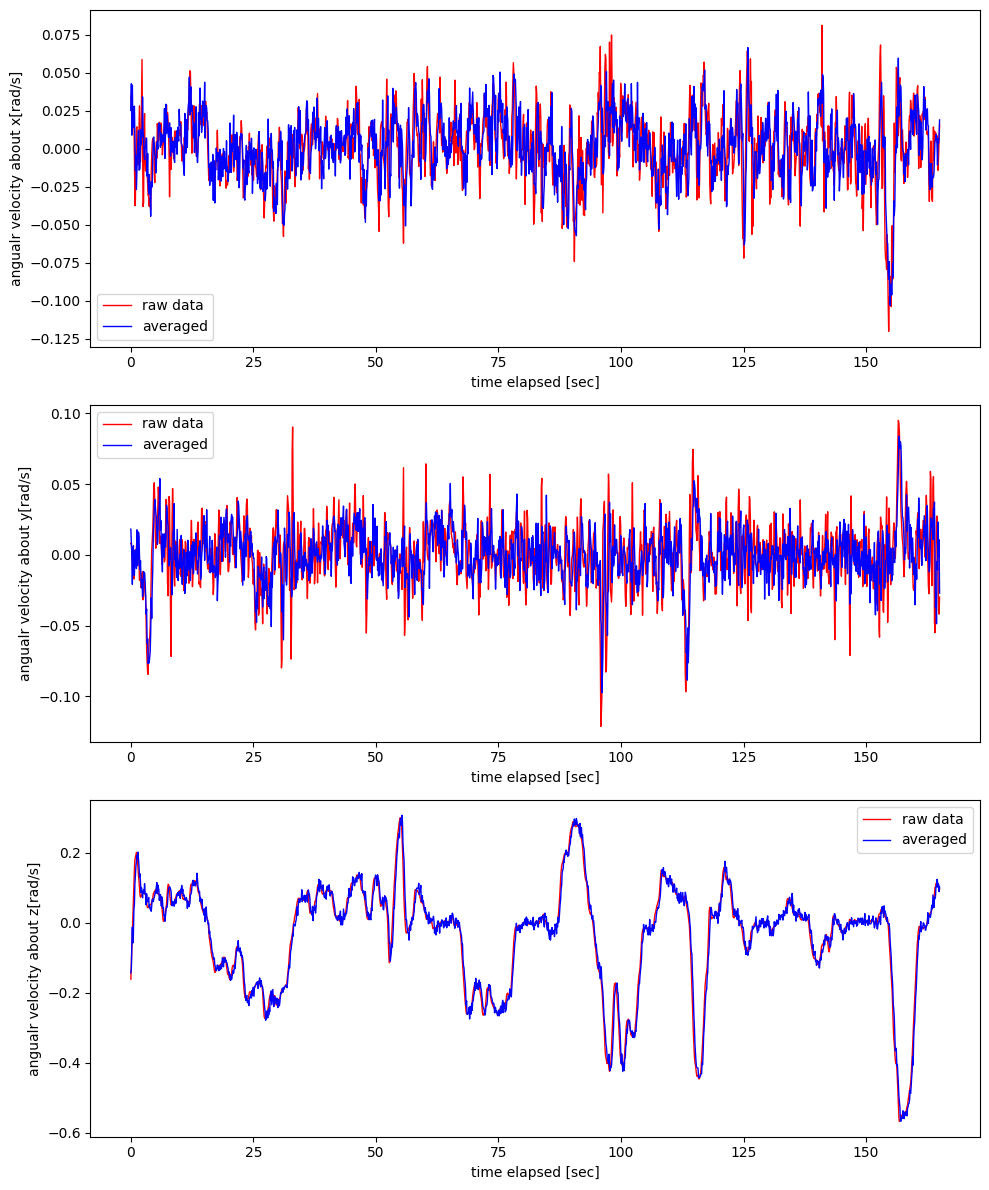

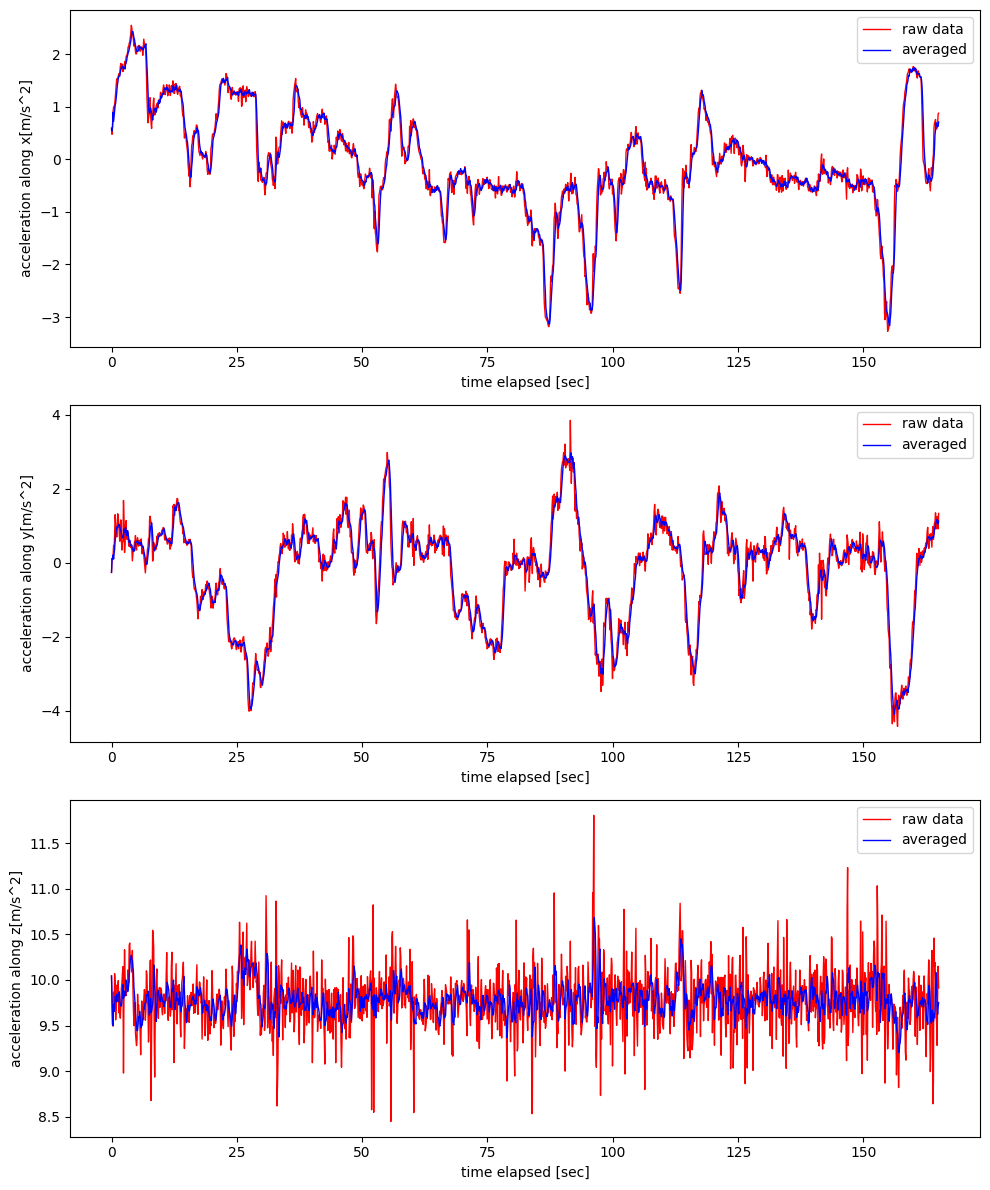

In [5]:
data.change_smoothing_window_size(window_size=5)
data.set_data_sampling(sampling=SamplingEnum.LOOSELY_COUPLED)

In [6]:
x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(setup=SetupEnum.SETUP_1, 
                                                                        filter_type=FilterEnum.EKF, 
                                                                        noise_type=NoiseTypeEnum.CURRENT)
x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(setup=SetupEnum.SETUP_2, 
                                                                        filter_type=FilterEnum.EKF, 
                                                                        noise_type=NoiseTypeEnum.CURRENT)
x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(setup=SetupEnum.SETUP_3, 
                                                                        filter_type=FilterEnum.EKF, 
                                                                        noise_type=NoiseTypeEnum.CURRENT)

ekf1_5 = ExtendedKalmanFilter(
    x=x_setup1.copy(),
    P=P_setup1.copy(), 
    H=H_setup1.copy(),
    q=q1,
    r_vo=r_vo1,
    r_gps=r_gps1,
    setup=SetupEnum.SETUP_1)

ekf2_5 = ExtendedKalmanFilter(
    x=x_setup2.copy(), 
    P=P_setup2.copy(), 
    H=H_setup2.copy(),
    q=q2,
    r_vo=r_vo2,
    r_gps=r_gps2,
    setup=SetupEnum.SETUP_2)

ekf3_5 = ExtendedKalmanFilter(
    x=x_setup3.copy(), 
    P=P_setup3.copy(), 
    H=H_setup3.copy(),
    q=q3,
    r_vo=r_vo3,
    r_gps=r_gps3,
    setup=SetupEnum.SETUP_3)


error_ekf_1_5 = ekf1_5.run(data=data, debug_mode=True, show_graph=False)
error_ekf_2_5 = ekf2_5.run(data=data, debug_mode=True, show_graph=False)
error_ekf_3_5 = ekf3_5.run(data=data, debug_mode=True, show_graph=False)



x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(setup=SetupEnum.SETUP_1, 
                                                                        filter_type=FilterEnum.UKF, 
                                                                        noise_type=NoiseTypeEnum.CURRENT)
x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(setup=SetupEnum.SETUP_2, 
                                                                        filter_type=FilterEnum.UKF, 
                                                                        noise_type=NoiseTypeEnum.CURRENT)
x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(setup=SetupEnum.SETUP_3, 
                                                                        filter_type=FilterEnum.UKF, 
                                                                        noise_type=NoiseTypeEnum.CURRENT)


ukf1_5 = UnscentedKalmanFilter(
    x=x_setup1.copy(), 
    P=P_setup1.copy(), 
    H=H_setup1.copy(), 
    q=q1,
    r_vo=r_vo1,
    r_gps=r_gps1,
    alpha=alpha_setup1_0, 
    beta=beta_setup1_0, 
    kappa=kappa_setup1_0,
    setup=SetupEnum.SETUP_1)

ukf2_5 = UnscentedKalmanFilter(
    x=x_setup2.copy(), 
    P=P_setup2.copy(), 
    H=H_setup2.copy(), 
    q=q2,
    r_vo=r_vo2,
    r_gps=r_gps2,
    alpha=alpha_setup2_0, 
    beta=beta_setup2_0, 
    kappa=kappa_setup2_0,
    setup=SetupEnum.SETUP_2)

ukf3_5 = UnscentedKalmanFilter(
    x=x_setup3.copy(), 
    P=P_setup3.copy(), 
    H=H_setup3.copy(), 
    q=q3,
    r_vo=r_vo3,
    r_gps=r_gps3,
    alpha=alpha_setup3_0, 
    beta=beta_setup3_0, 
    kappa=kappa_setup3_0,
    setup=SetupEnum.SETUP_3)

error_ukf_1_5 = ukf1_5.run(data=data, debug_mode=True, show_graph=False)
error_ukf_2_5 = ukf2_5.run(data=data, debug_mode=True, show_graph=False)
error_ukf_3_5 = ukf3_5.run(data=data, debug_mode=True, show_graph=False)



x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(setup=SetupEnum.SETUP_1, 
                                                                        filter_type=FilterEnum.PF, 
                                                                        noise_type=NoiseTypeEnum.CURRENT)
x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(setup=SetupEnum.SETUP_2, 
                                                                        filter_type=FilterEnum.PF, 
                                                                        noise_type=NoiseTypeEnum.CURRENT)
x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(setup=SetupEnum.SETUP_3, 
                                                                        filter_type=FilterEnum.PF, 
                                                                        noise_type=NoiseTypeEnum.CURRENT)

pf1_5 = ParticleFilter(
    N=n_samples_setup1_0, 
    x_dim=x_setup1.shape[0], 
    H=H_setup1.copy(), 
    q=q1,
    r_vo=r_vo1,
    r_gps=r_gps1,
    setup=SetupEnum.SETUP_1,
    resampling_algorithm=resampling_algorithm_setup1_0)

pf1_5.create_gaussian_particles(mean=x_setup1.copy(), var=P_setup1.copy())

pf2_5 = ParticleFilter(
    N=n_samples_setup2_0, 
    x_dim=x_setup2.shape[0], 
    H=H_setup2.copy(), 
    q=q2,
    r_vo=r_vo2,
    r_gps=r_gps2,
    setup=SetupEnum.SETUP_2,
    resampling_algorithm=resampling_algorithm_setup2_0)

pf2_5.create_gaussian_particles(mean=x_setup2.copy(), var=P_setup2.copy())

pf3_5 = ParticleFilter(
    N=n_samples_setup3_0, 
    x_dim=x_setup3.shape[0], 
    H=H_setup3.copy(), 
    q=q3,
    r_vo=r_vo3,
    r_gps=r_gps3,
    setup=SetupEnum.SETUP_3,
    resampling_algorithm=resampling_algorithm_setup3_0)

pf3_5.create_gaussian_particles(mean=x_setup3.copy(), var=P_setup3.copy())

error_pf_1_5 = pf1_5.run(data=data, debug_mode=True, show_graph=False)
error_pf_2_5 = pf2_5.run(data=data, debug_mode=True, show_graph=False)
error_pf_3_5 = pf3_5.run(data=data, debug_mode=True, show_graph=False)



x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(setup=SetupEnum.SETUP_1, 
                                                                        filter_type=FilterEnum.EnKF, 
                                                                        noise_type=NoiseTypeEnum.CURRENT)
x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(setup=SetupEnum.SETUP_2, 
                                                                        filter_type=FilterEnum.EnKF, 
                                                                        noise_type=NoiseTypeEnum.CURRENT)
x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(setup=SetupEnum.SETUP_3, 
                                                                        filter_type=FilterEnum.EnKF, 
                                                                        noise_type=NoiseTypeEnum.CURRENT)


enkf1_5 = EnsembleKalmanFilter(        
    N=n_ensemble_setup1_0, 
    x=x_setup1.copy(), 
    P=P_setup1.copy(), 
    H=H_setup1.copy(),
    q=q1,
    r_vo=r_vo1,
    r_gps=r_gps1,
    setup=SetupEnum.SETUP_1)
enkf2_5 = EnsembleKalmanFilter(
    N=n_ensemble_setup2_0, 
    x=x_setup2.copy(), 
    P=P_setup2.copy(), 
    H=H_setup2.copy(),
    q=q2,
    r_vo=r_vo2,
    r_gps=r_gps2,
    setup=SetupEnum.SETUP_2)

enkf3_5 = EnsembleKalmanFilter(
    N=n_ensemble_setup3_0, 
    x=x_setup3.copy(), 
    P=P_setup3.copy(), 
    H=H_setup3.copy(),
    q=q3,
    r_vo=r_vo3,
    r_gps=r_gps3,
    setup=SetupEnum.SETUP_3)

error_enkf_1_5 = enkf1_5.run(data=data, debug_mode=True, show_graph=False)
error_enkf_2_5 = enkf2_5.run(data=data, debug_mode=True, show_graph=False)
error_enkf_3_5 = enkf3_5.run(data=data, debug_mode=True, show_graph=False)



x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(setup=SetupEnum.SETUP_1, 
                                                                        filter_type=FilterEnum.CKF, 
                                                                        noise_type=NoiseTypeEnum.CURRENT)
x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(setup=SetupEnum.SETUP_2, 
                                                                        filter_type=FilterEnum.CKF, 
                                                                        noise_type=NoiseTypeEnum.CURRENT)
x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(setup=SetupEnum.SETUP_3, 
                                                                        filter_type=FilterEnum.CKF,
                                                                        noise_type=NoiseTypeEnum.CURRENT)

ckf1_5 = CubatureKalmanFilter(
    x=x_setup1.copy(), 
    P=P_setup1.copy(), 
    H=H_setup1.copy(),
    q=q1,
    r_vo=r_vo1,
    r_gps=r_gps1,
    setup=SetupEnum.SETUP_1)

ckf2_5 = CubatureKalmanFilter(
    x=x_setup2.copy(), 
    P=P_setup2.copy(), 
    H=H_setup2.copy(),
    q=q2,
    r_vo=r_vo2,
    r_gps=r_gps2,
    setup=SetupEnum.SETUP_2)

ckf3_5 = CubatureKalmanFilter( 
    x=x_setup3.copy(), 
    P=P_setup3.copy(), 
    H=H_setup3.copy(),
    q=q3,
    r_vo=r_vo3,
    r_gps=r_gps3,
    setup=SetupEnum.SETUP_3)


error_ckf_1_5 = ckf1_5.run(data=data, debug_mode=True, show_graph=False)
error_ckf_2_5 = ckf2_5.run(data=data, debug_mode=True, show_graph=False)
error_ckf_3_5 = ckf3_5.run(data=data, debug_mode=True, show_graph=False)


error_1_smoothed_5 = [error_ekf_1_5, error_ukf_1_5, error_pf_1_5, error_enkf_1_5, error_ckf_1_5]
error_2_smoothed_5 = [error_ekf_2_5, error_ukf_2_5, error_pf_2_5, error_enkf_2_5, error_ckf_2_5]
error_3_smoothed_5 = [error_ekf_3_5, error_ukf_3_5, error_pf_3_5, error_enkf_3_5, error_ckf_3_5]

[EKF] start.


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 14045.32it/s]


[EKF] errors: {<ErrorEnum.MAE: 1>: 3.88, <ErrorEnum.RMSE: 2>: 5.518, <ErrorEnum.MAX: 3>: 16.485}
[EKF] start.


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 11497.15it/s]


[EKF] errors: {<ErrorEnum.MAE: 1>: 1.979, <ErrorEnum.RMSE: 2>: 2.796, <ErrorEnum.MAX: 3>: 8.854}
[EKF] start.


...

[CKF] errors: {<ErrorEnum.MAE: 1>: 3.882, <ErrorEnum.RMSE: 2>: 5.479, <ErrorEnum.MAX: 3>: 16.332}
[CKF] start.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 2493.10it/s]


[CKF] errors: {<ErrorEnum.MAE: 1>: 1.453, <ErrorEnum.RMSE: 2>: 1.96, <ErrorEnum.MAX: 3>: 6.402}
[CKF] start.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 6041.61it/s]

[CKF] errors: {<ErrorEnum.MAE: 1>: 1.547, <ErrorEnum.RMSE: 2>: 2.108, <ErrorEnum.MAX: 3>: 6.615}


## window_size = 10

IMU/INS data is now smoothed


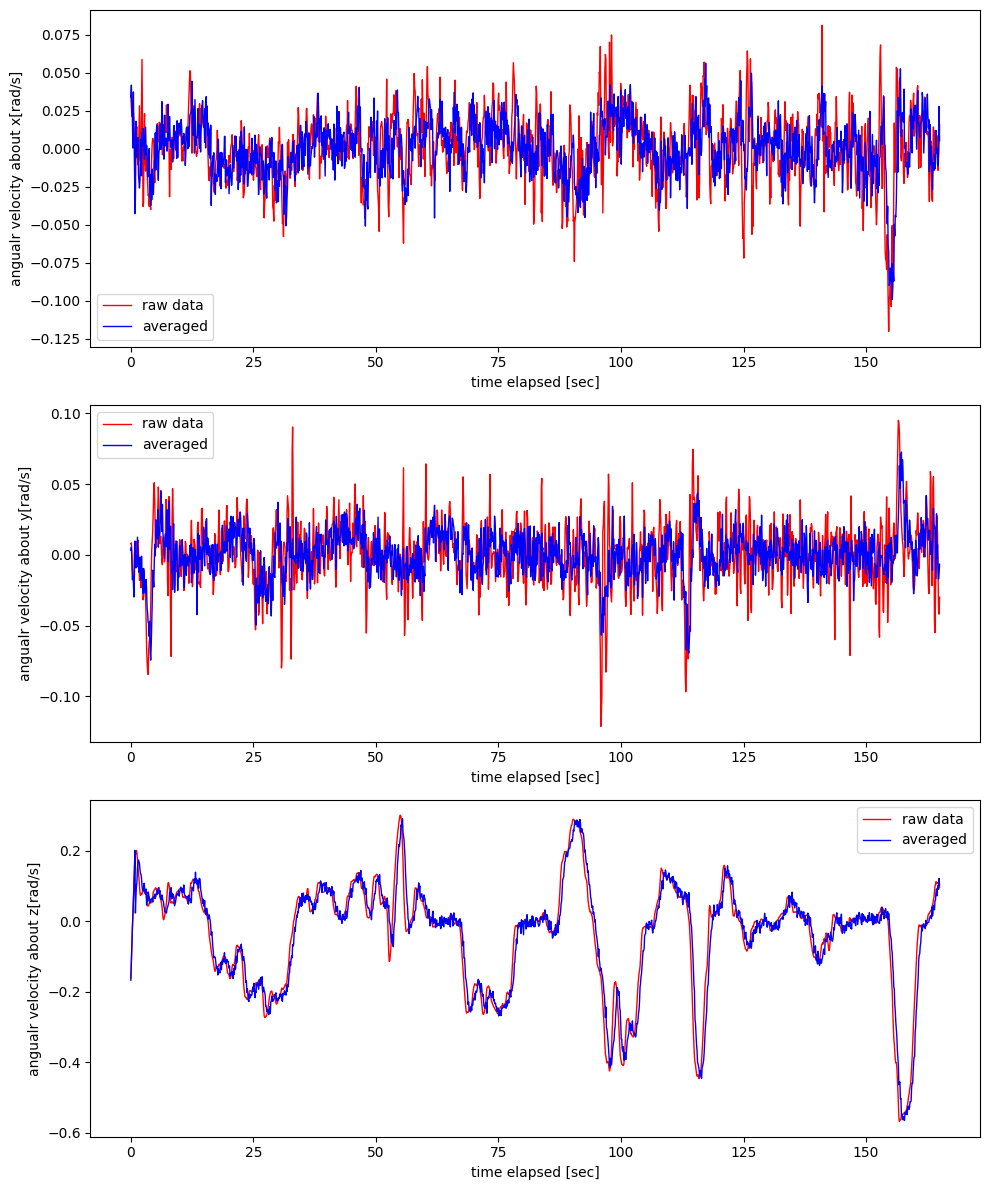

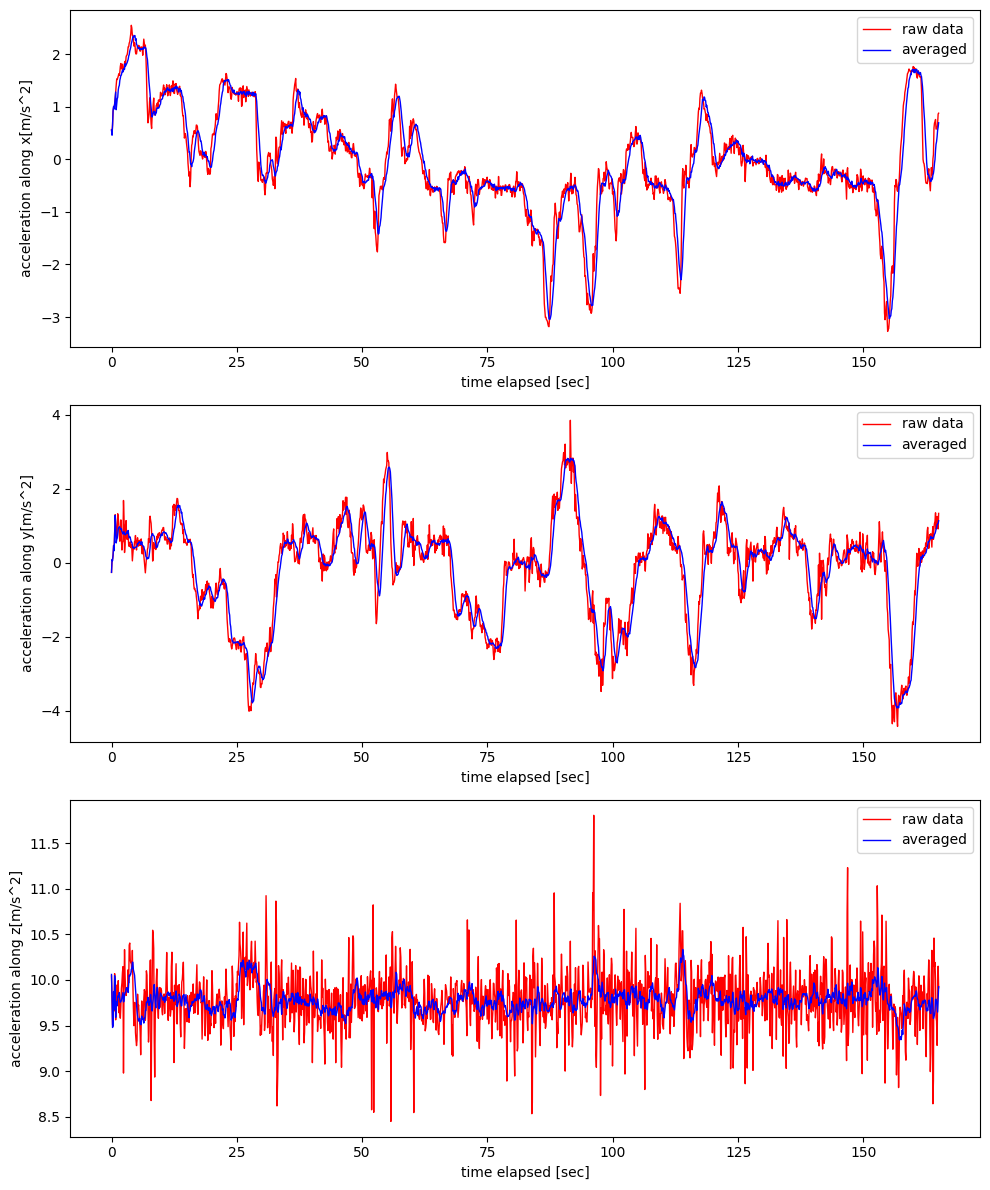

In [7]:
data.change_smoothing_window_size(window_size=10)
data.set_data_sampling(sampling=SamplingEnum.LOOSELY_COUPLED)

In [8]:
x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(setup=SetupEnum.SETUP_1, 
                                                                        filter_type=FilterEnum.EKF, 
                                                                        noise_type=NoiseTypeEnum.CURRENT)
x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(setup=SetupEnum.SETUP_2, 
                                                                        filter_type=FilterEnum.EKF, 
                                                                        noise_type=NoiseTypeEnum.CURRENT)
x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(setup=SetupEnum.SETUP_3, 
                                                                        filter_type=FilterEnum.EKF, 
                                                                        noise_type=NoiseTypeEnum.CURRENT)

ekf1_10 = ExtendedKalmanFilter(
    x=x_setup1.copy(),
    P=P_setup1.copy(), 
    H=H_setup1.copy(),
    q=q1,
    r_vo=r_vo1,
    r_gps=r_gps1,
    setup=SetupEnum.SETUP_1)

ekf2_10 = ExtendedKalmanFilter(
    x=x_setup2.copy(), 
    P=P_setup2.copy(), 
    H=H_setup2.copy(),
    q=q2,
    r_vo=r_vo2,
    r_gps=r_gps2,
    setup=SetupEnum.SETUP_2)

ekf3_10 = ExtendedKalmanFilter(
    x=x_setup3.copy(), 
    P=P_setup3.copy(), 
    H=H_setup3.copy(),
    q=q3,
    r_vo=r_vo3,
    r_gps=r_gps3,
    setup=SetupEnum.SETUP_3)


error_ekf_1_10 = ekf1_10.run(data=data, debug_mode=True, show_graph=False)
error_ekf_2_10 = ekf2_10.run(data=data, debug_mode=True, show_graph=False)
error_ekf_3_10 = ekf3_10.run(data=data, debug_mode=True, show_graph=False)



x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(setup=SetupEnum.SETUP_1, 
                                                                        filter_type=FilterEnum.UKF, 
                                                                        noise_type=NoiseTypeEnum.CURRENT)
x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(setup=SetupEnum.SETUP_2, 
                                                                        filter_type=FilterEnum.UKF, 
                                                                        noise_type=NoiseTypeEnum.CURRENT)
x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(setup=SetupEnum.SETUP_3, 
                                                                        filter_type=FilterEnum.UKF, 
                                                                        noise_type=NoiseTypeEnum.CURRENT)


ukf1_10 = UnscentedKalmanFilter(
    x=x_setup1.copy(), 
    P=P_setup1.copy(), 
    H=H_setup1.copy(), 
    q=q1,
    r_vo=r_vo1,
    r_gps=r_gps1,
    alpha=alpha_setup1_0, 
    beta=beta_setup1_0, 
    kappa=kappa_setup1_0,
    setup=SetupEnum.SETUP_1)

ukf2_10 = UnscentedKalmanFilter(
    x=x_setup2.copy(), 
    P=P_setup2.copy(), 
    H=H_setup2.copy(), 
    q=q2,
    r_vo=r_vo2,
    r_gps=r_gps2,
    alpha=alpha_setup2_0, 
    beta=beta_setup2_0, 
    kappa=kappa_setup2_0,
    setup=SetupEnum.SETUP_2)

ukf3_10 = UnscentedKalmanFilter(
    x=x_setup3.copy(), 
    P=P_setup3.copy(), 
    H=H_setup3.copy(), 
    q=q3,
    r_vo=r_vo3,
    r_gps=r_gps3,
    alpha=alpha_setup3_0, 
    beta=beta_setup3_0, 
    kappa=kappa_setup3_0,
    setup=SetupEnum.SETUP_3)

error_ukf_1_10 = ukf1_10.run(data=data, debug_mode=True, show_graph=False)
error_ukf_2_10 = ukf2_10.run(data=data, debug_mode=True, show_graph=False)
error_ukf_3_10 = ukf3_10.run(data=data, debug_mode=True, show_graph=False)



x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(setup=SetupEnum.SETUP_1, 
                                                                        filter_type=FilterEnum.PF, 
                                                                        noise_type=NoiseTypeEnum.CURRENT)
x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(setup=SetupEnum.SETUP_2, 
                                                                        filter_type=FilterEnum.PF, 
                                                                        noise_type=NoiseTypeEnum.CURRENT)
x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(setup=SetupEnum.SETUP_3, 
                                                                        filter_type=FilterEnum.PF, 
                                                                        noise_type=NoiseTypeEnum.CURRENT)

pf1_10 = ParticleFilter(
    N=n_samples_setup1_0, 
    x_dim=x_setup1.shape[0], 
    H=H_setup1.copy(), 
    q=q1,
    r_vo=r_vo1,
    r_gps=r_gps1,
    setup=SetupEnum.SETUP_1,
    resampling_algorithm=resampling_algorithm_setup1_0)

pf1_10.create_gaussian_particles(mean=x_setup1.copy(), var=P_setup1.copy())

pf2_10 = ParticleFilter(
    N=n_samples_setup2_0, 
    x_dim=x_setup2.shape[0], 
    H=H_setup2.copy(), 
    q=q2,
    r_vo=r_vo2,
    r_gps=r_gps2,
    setup=SetupEnum.SETUP_2,
    resampling_algorithm=resampling_algorithm_setup2_0)

pf2_10.create_gaussian_particles(mean=x_setup2.copy(), var=P_setup2.copy())

pf3_10 = ParticleFilter(
    N=n_samples_setup3_0, 
    x_dim=x_setup3.shape[0], 
    H=H_setup3.copy(), 
    q=q3,
    r_vo=r_vo3,
    r_gps=r_gps3,
    setup=SetupEnum.SETUP_3,
    resampling_algorithm=resampling_algorithm_setup3_0)

pf3_10.create_gaussian_particles(mean=x_setup3.copy(), var=P_setup3.copy())

error_pf_1_10 = pf1_10.run(data=data, debug_mode=True, show_graph=False)
error_pf_2_10 = pf2_10.run(data=data, debug_mode=True, show_graph=False)
error_pf_3_10 = pf3_10.run(data=data, debug_mode=True, show_graph=False)



x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(setup=SetupEnum.SETUP_1, 
                                                                        filter_type=FilterEnum.EnKF, 
                                                                        noise_type=NoiseTypeEnum.CURRENT)
x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(setup=SetupEnum.SETUP_2, 
                                                                        filter_type=FilterEnum.EnKF, 
                                                                        noise_type=NoiseTypeEnum.CURRENT)
x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(setup=SetupEnum.SETUP_3, 
                                                                        filter_type=FilterEnum.EnKF, 
                                                                        noise_type=NoiseTypeEnum.CURRENT)


enkf1_10 = EnsembleKalmanFilter(        
    N=n_ensemble_setup1_0, 
    x=x_setup1.copy(), 
    P=P_setup1.copy(), 
    H=H_setup1.copy(),
    q=q1,
    r_vo=r_vo1,
    r_gps=r_gps1,
    setup=SetupEnum.SETUP_1)
enkf2_10 = EnsembleKalmanFilter(
    N=n_ensemble_setup2_0, 
    x=x_setup2.copy(), 
    P=P_setup2.copy(), 
    H=H_setup2.copy(),
    q=q2,
    r_vo=r_vo2,
    r_gps=r_gps2,
    setup=SetupEnum.SETUP_2)

enkf3_10 = EnsembleKalmanFilter(
    N=n_ensemble_setup3_0, 
    x=x_setup3.copy(), 
    P=P_setup3.copy(), 
    H=H_setup3.copy(),
    q=q3,
    r_vo=r_vo3,
    r_gps=r_gps3,
    setup=SetupEnum.SETUP_3)

error_enkf_1_10 = enkf1_10.run(data=data, debug_mode=True, show_graph=False)
error_enkf_2_10 = enkf2_10.run(data=data, debug_mode=True, show_graph=False)
error_enkf_3_10 = enkf3_10.run(data=data, debug_mode=True, show_graph=False)



x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(setup=SetupEnum.SETUP_1, 
                                                                        filter_type=FilterEnum.CKF, 
                                                                        noise_type=NoiseTypeEnum.CURRENT)
x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(setup=SetupEnum.SETUP_2, 
                                                                        filter_type=FilterEnum.CKF, 
                                                                        noise_type=NoiseTypeEnum.CURRENT)
x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(setup=SetupEnum.SETUP_3, 
                                                                        filter_type=FilterEnum.CKF, 
                                                                        noise_type=NoiseTypeEnum.CURRENT)

ckf1_10 = CubatureKalmanFilter(
    x=x_setup1.copy(), 
    P=P_setup1.copy(), 
    H=H_setup1.copy(),
    q=q1,
    r_vo=r_vo1,
    r_gps=r_gps1,
    setup=SetupEnum.SETUP_1)

ckf2_10 = CubatureKalmanFilter(
    x=x_setup2.copy(), 
    P=P_setup2.copy(), 
    H=H_setup2.copy(),
    q=q2,
    r_vo=r_vo2,
    r_gps=r_gps2,
    setup=SetupEnum.SETUP_2)

ckf3_10 = CubatureKalmanFilter( 
    x=x_setup3.copy(), 
    P=P_setup3.copy(), 
    H=H_setup3.copy(),
    q=q3,
    r_vo=r_vo3,
    r_gps=r_gps3,
    setup=SetupEnum.SETUP_3)


error_ckf_1_10 = ckf1_10.run(data=data, debug_mode=True, show_graph=False)
error_ckf_2_10 = ckf2_10.run(data=data, debug_mode=True, show_graph=False)
error_ckf_3_10 = ckf3_10.run(data=data, debug_mode=True, show_graph=False)


error_1_smoothed_10 = [error_ekf_1_10, error_ukf_1_10, error_pf_1_10, error_enkf_1_10, error_ckf_1_10]
error_2_smoothed_10 = [error_ekf_2_10, error_ukf_2_10, error_pf_2_10, error_enkf_2_10, error_ckf_2_10]
error_3_smoothed_10 = [error_ekf_3_10, error_ukf_3_10, error_pf_3_10, error_enkf_3_10, error_ckf_3_10]

[EKF] start.


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 11716.78it/s]


[EKF] errors: {<ErrorEnum.MAE: 1>: 3.877, <ErrorEnum.RMSE: 2>: 5.513, <ErrorEnum.MAX: 3>: 16.469}
[EKF] start.


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 10431.98it/s]


[EKF] errors: {<ErrorEnum.MAE: 1>: 1.981, <ErrorEnum.RMSE: 2>: 2.802, <ErrorEnum.MAX: 3>: 8.968}
[EKF] start.


...

[CKF] errors: {<ErrorEnum.MAE: 1>: 3.891, <ErrorEnum.RMSE: 2>: 5.515, <ErrorEnum.MAX: 3>: 16.51}
[CKF] start.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 2055.66it/s]


[CKF] errors: {<ErrorEnum.MAE: 1>: 1.452, <ErrorEnum.RMSE: 2>: 1.957, <ErrorEnum.MAX: 3>: 6.437}
[CKF] start.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 6428.06it/s]

[CKF] errors: {<ErrorEnum.MAE: 1>: 1.546, <ErrorEnum.RMSE: 2>: 2.107, <ErrorEnum.MAX: 3>: 6.678}


In [9]:
mae_smoothed_5_1 = np.array(get_error_from_list(error_1_smoothed_5, e_type=ErrorEnum.MAE))
mae_smoothed_10_1 = np.array(get_error_from_list(error_1_smoothed_10, e_type=ErrorEnum.MAE))
mae_current_1 = np.array(get_error_from_list(error_current_1, e_type=ErrorEnum.MAE))

mae_diff_5_1 = mae_smoothed_5_1 - mae_current_1
mae_diff_10_1 = mae_smoothed_10_1 - mae_current_1
mae_diff_1 = np.array([mae_current_1, mae_diff_5_1, mae_diff_10_1]).T

rmse_smoothed_5_1 = np.array(get_error_from_list(error_1_smoothed_5, e_type=ErrorEnum.RMSE))
rmse_smoothed_10_1 = np.array(get_error_from_list(error_1_smoothed_10, e_type=ErrorEnum.RMSE))
rmse_current_1 = np.array(get_error_from_list(error_current_1, e_type=ErrorEnum.RMSE))

rmse_diff_5_1 = rmse_smoothed_5_1 - rmse_current_1
rmse_diff_10_1 = rmse_smoothed_10_1 - rmse_current_1
rmse_diff_1 = np.array([rmse_current_1, rmse_diff_5_1, rmse_diff_10_1]).T


max_smoothed_5_1 = np.array(get_error_from_list(error_1_smoothed_5, e_type=ErrorEnum.MAX))
max_smoothed_10_1 = np.array(get_error_from_list(error_1_smoothed_10, e_type=ErrorEnum.MAX))
max_current_1 = np.array(get_error_from_list(error_current_1, e_type=ErrorEnum.MAX))

max_diff_5_1 = max_smoothed_5_1 - max_current_1
max_diff_10_1 = max_smoothed_10_1 - max_current_1
max_diff_1 = np.array([max_current_1, max_diff_5_1, max_diff_10_1]).T

diffs_1 = np.concatenate([mae_diff_1, rmse_diff_1, max_diff_1], axis=1)

In [10]:
mae_smoothed_5_2 = np.array(get_error_from_list(error_2_smoothed_5, e_type=ErrorEnum.MAE))
mae_smoothed_10_2 = np.array(get_error_from_list(error_2_smoothed_10, e_type=ErrorEnum.MAE))
mae_current_2 = np.array(get_error_from_list(error_current_2, e_type=ErrorEnum.MAE))

mae_diff_5_2 = mae_smoothed_5_2 - mae_current_2
mae_diff_10_2 = mae_smoothed_10_2 - mae_current_2
mae_diff_2 = np.array([mae_current_2, mae_diff_5_2, mae_diff_10_2]).T

rmse_smoothed_5_2 = np.array(get_error_from_list(error_2_smoothed_5, e_type=ErrorEnum.RMSE))
rmse_smoothed_10_2 = np.array(get_error_from_list(error_2_smoothed_10, e_type=ErrorEnum.RMSE))
rmse_current_2 = np.array(get_error_from_list(error_current_2, e_type=ErrorEnum.RMSE))

rmse_diff_5_2 = rmse_smoothed_5_2 - rmse_current_2
rmse_diff_10_2 = rmse_smoothed_10_2 - rmse_current_2
rmse_diff_2 = np.array([rmse_current_2, rmse_diff_5_2, rmse_diff_10_2]).T


max_smoothed_5_2 = np.array(get_error_from_list(error_2_smoothed_5, e_type=ErrorEnum.MAX))
max_smoothed_10_2 = np.array(get_error_from_list(error_2_smoothed_10, e_type=ErrorEnum.MAX))
max_current_2 = np.array(get_error_from_list(error_current_2, e_type=ErrorEnum.MAX))

max_diff_5_2 = max_smoothed_5_2 - max_current_2
max_diff_10_2 = max_smoothed_10_2 - max_current_2
max_diff_2 = np.array([max_current_2, max_diff_5_2, max_diff_10_2]).T

diffs_2 = np.concatenate([mae_diff_2, rmse_diff_2, max_diff_2], axis=1)

In [11]:
mae_smoothed_5_3 = np.array(get_error_from_list(error_3_smoothed_5, e_type=ErrorEnum.MAE))
mae_smoothed_10_3 = np.array(get_error_from_list(error_3_smoothed_10, e_type=ErrorEnum.MAE))
mae_current_3 = np.array(get_error_from_list(error_current_3, e_type=ErrorEnum.MAE))

mae_diff_5_3 = mae_smoothed_5_3 - mae_current_3
mae_diff_10_3 = mae_smoothed_10_3 - mae_current_3
mae_diff_3 = np.array([mae_current_3, mae_diff_5_3, mae_diff_10_3]).T

rmse_smoothed_5_3 = np.array(get_error_from_list(error_3_smoothed_5, e_type=ErrorEnum.RMSE))
rmse_smoothed_10_3 = np.array(get_error_from_list(error_3_smoothed_10, e_type=ErrorEnum.RMSE))
rmse_current_3 = np.array(get_error_from_list(error_current_3, e_type=ErrorEnum.RMSE))

rmse_diff_5_3 = rmse_smoothed_5_3 - rmse_current_3
rmse_diff_10_3 = rmse_smoothed_10_3 - rmse_current_3
rmse_diff_3 = np.array([rmse_current_3, rmse_diff_5_3, rmse_diff_10_3]).T


max_smoothed_5_3 = np.array(get_error_from_list(error_3_smoothed_5, e_type=ErrorEnum.MAX))
max_smoothed_10_3 = np.array(get_error_from_list(error_3_smoothed_10, e_type=ErrorEnum.MAX))
max_current_3 = np.array(get_error_from_list(error_current_3, e_type=ErrorEnum.MAX))

max_diff_5_3 = max_smoothed_5_3 - max_current_3
max_diff_10_3 = max_smoothed_10_3 - max_current_3
max_diff_3 = np.array([max_current_3, max_diff_5_3, max_diff_10_3]).T

diffs_3 = np.concatenate([mae_diff_3, rmse_diff_3, max_diff_3], axis=1)

In [12]:
header = pd.MultiIndex.from_product([['MAE','RMSE', 'MAX'],
                                   ["original", "∆(window=5)", "∆(window=10)"]],
                                   names=['Error types', 'IMU data smoothing types'])

In [13]:
df1 = pd.DataFrame(diffs_1, index=["EKF", "UKF", "PF", "EnKF", "CKF"], columns=header)
df1

Error types                   MAE                              RMSE  \
IMU data smoothing types original ∆(window=5) ∆(window=10) original   
EKF                         3.883      -0.003       -0.006    5.523   
UKF                         3.900       0.017        0.031    5.500   
PF                          3.870       0.004        0.003    5.491   
EnKF                        4.130      -0.025       -0.020    5.687   
CKF                         3.860       0.022        0.031    5.427   

Error types                                            MAX              \
IMU data smoothing types ∆(window=5) ∆(window=10) original ∆(window=5)   
EKF                           -0.005       -0.010   16.490      -0.005   
UKF                            0.034        0.000   16.296       0.386   
PF                            -0.009       -0.003   16.018       0.159   
EnKF                          -0.019       -0.009   18.723      -0.324   
CKF                            0.052        0.088   16.714      -0.382   

Error types                            
IMU data smoothing types ∆(window=10)  
EKF                            -0.021  
UKF                             0.030  
PF                              0.158  
EnKF                            0.039  
CKF                            -0.204

In [14]:
df2 = pd.DataFrame(diffs_2, index=["EKF", "UKF", "PF", "EnKF", "CKF"], columns=header)
df2

Error types                   MAE                              RMSE  \
IMU data smoothing types original ∆(window=5) ∆(window=10) original   
EKF                         1.982      -0.003       -0.001    2.805   
UKF                         1.443       0.008        0.015    1.932   
PF                          0.442       0.007        0.001    0.554   
EnKF                        1.908      -0.011        0.004    2.595   
CKF                         1.462      -0.009       -0.010    1.975   

Error types                                            MAX              \
IMU data smoothing types ∆(window=5) ∆(window=10) original ∆(window=5)   
EKF                           -0.009       -0.003    8.911      -0.057   
UKF                            0.025        0.036    6.274      -0.010   
PF                             0.011        0.004    2.023       0.054   
EnKF                          -0.067       -0.059   17.409      -1.146   
CKF                           -0.015       -0.018    6.469      -0.067   

Error types                            
IMU data smoothing types ∆(window=10)  
EKF                             0.057  
UKF                             0.066  
PF                              0.171  
EnKF                           -2.763  
CKF                            -0.032

In [15]:
df3 = pd.DataFrame(diffs_3, index=["EKF", "UKF", "PF", "EnKF", "CKF"], columns=header)
df3

Error types                   MAE                              RMSE  \
IMU data smoothing types original ∆(window=5) ∆(window=10) original   
EKF                         1.942       0.009        0.015    2.751   
UKF                         1.565      -0.006        0.001    2.151   
PF                          0.289       0.016        0.056    0.368   
EnKF                        1.105       0.003        0.004    1.411   
CKF                         1.546       0.001        0.000    2.108   

Error types                                            MAX              \
IMU data smoothing types ∆(window=5) ∆(window=10) original ∆(window=5)   
EKF                            0.000        0.001    8.198       0.059   
UKF                           -0.004        0.003    6.577       0.054   
PF                             0.015        0.063    1.500       0.117   
EnKF                          -0.002       -0.010    5.220       0.049   
CKF                            0.000       -0.001    6.591       0.024   

Error types                            
IMU data smoothing types ∆(window=10)  
EKF                             0.163  
UKF                             0.126  
PF                              0.135  
EnKF                            0.024  
CKF                             0.087

∆ (window=x) represents IMU data smoothed with the window size of x and the value is obtained by $error_{smoothed IMU} - error_{raw IMU}$.

From the experiment, the estimation error with smoothed IMU data does not experience a significant improvement. Therefore, we can conclude that smoothing the IMU data does not affect on the filter accuracy.